# busi_B-FWGAN

# ส่วนใหม่

In [ ]:
!pip -q install torch torchvision --extra-index-url https://download.pytorch.org/whl/cu121
!pip -q install scikit-image tqdm Pillow numpy scikit-learn

In [ ]:
# ==== USER PATHS ====
ZIP_PATH    = "/content/drive/MyDrive/BUSI/archive.zip"     # your dataset zip
EXTRACT_DIR = "/content/drive/MyDrive/BUSI/BUSI_raw"        # where to extract
WORK_DIR    = "/content/drive/MyDrive/BUSI/busi_noaug_outputs"  # all outputs here

# ==== Colab basics ====
from google.colab import drive
drive.mount('/content/drive')

!pip -q install tqdm scikit-image

import os, shutil, math, random, json, csv, glob, time
from pathlib import Path

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(WORK_DIR, exist_ok=True)

DATASET_DIR = os.path.join(EXTRACT_DIR, "BUSI")  # expecting BUSI/benign, BUSI/malignant, BUSI/normal
SPLITS_DIR  = os.path.join(WORK_DIR, "splits")
GAN_OUT_DIR = os.path.join(WORK_DIR, "fwgan_outputs")
SYNTH_DIR   = os.path.join(WORK_DIR, "synth_curated")
CLF_OUT_DIR = os.path.join(WORK_DIR, "clf_outputs")

for d in [SPLITS_DIR, GAN_OUT_DIR, SYNTH_DIR, CLF_OUT_DIR]:
    os.makedirs(d, exist_ok=True)

CLASSES = ["benign","malignant","normal"]
print("DATASET_DIR =", DATASET_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATASET_DIR = /content/drive/MyDrive/BUSI/BUSI_raw/BUSI


In [ ]:
def is_image(p: Path):
    return p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}

# Find all candidate class dirs
candidate_dirs = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    # heuristic: a "class dir" contains mostly images or contains mask+image files
    if any(d.lower() in ("benign","malignant","normal") for d in dirs):
        # parent that holds class subdirs
        candidate_dirs.append(root)

# If we discovered parents that contain class subdirs, pick the shallowest
if candidate_dirs:
    base_dir = sorted(candidate_dirs, key=lambda p: len(Path(p).parts))[0]
else:
    # fallback: maybe EXTRACT_DIR itself has class dirs
    base_dir = EXTRACT_DIR

print("Base directory for class folders:", base_dir)

# Build mapping
class_names = ["benign", "malignant", "normal"]
class_to_idx = {c:i for i,c in enumerate(class_names)}

all_samples = []  # list of (img_path, label_idx)
for cname in class_names:
    cdir = Path(base_dir) / cname
    if not cdir.exists():
        # try case-insensitive search
        matches = [Path(p) for p in glob.glob(os.path.join(base_dir, "**"), recursive=False)
                   if Path(p).name.lower() == cname]
        if matches:
            cdir = matches[0]
    if cdir.exists():
        for p in cdir.rglob("*"):
            if is_image(p) and ("mask" not in p.stem.lower()):
                all_samples.append((str(p), class_to_idx[cname]))

print(f"Found images (no masks): {len(all_samples)}")
counts = {c:0 for c in class_names}
for _, y in all_samples:
    counts[class_names[y]] += 1
print("Per-class counts:", counts)

Base directory for class folders: /content/drive/MyDrive/BUSI/BUSI_raw/Dataset_BUSI_with_GT
Found images (no masks): 780
Per-class counts: {'benign': 437, 'malignant': 210, 'normal': 133}


In [ ]:
# Use the base_dir you just printed
DATASET_DIR = "/content/drive/MyDrive/BUSI/BUSI_raw/Dataset_BUSI_with_GT"  # or: DATASET_DIR = base_dir
SPLITS_DIR  = f"{WORK_DIR}/splits"
os.makedirs(SPLITS_DIR, exist_ok=True)

# Reuse your all_samples list (already NO-MASK)
# all_samples is a list of (img_path, label_idx) you printed above.
import random, csv, os
from collections import defaultdict

random.seed(1337)

def stratified_split_from_list(items, train=0.7, val=0.1):
    buckets = defaultdict(list)
    random.shuffle(items)
    for p,l in items: buckets[l].append((p,l))
    train_set, val_set, test_set = [], [], []
    for l, rows in buckets.items():
        n = len(rows); n_tr = int(n*train); n_va = int(n*val)
        train_set += rows[:n_tr]
        val_set   += rows[n_tr:n_tr+n_va]
        test_set  += rows[n_tr+n_va:]
    return train_set, val_set, test_set

def write_csv(rows, path):
    with open(path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=["path","label"])
        w.writeheader()
        for p,l in rows: w.writerow({"path":p, "label":l})

tr, va, te = stratified_split_from_list(all_samples, 0.7, 0.1)
write_csv(tr, os.path.join(SPLITS_DIR,"train.csv"))
write_csv(va, os.path.join(SPLITS_DIR,"val.csv"))
write_csv(te, os.path.join(SPLITS_DIR,"test.csv"))

print("Split sizes:", {"train":len(tr), "val":len(va), "test":len(te)})


Split sizes: {'train': 545, 'val': 77, 'test': 158}


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
from pathlib import Path

gan_tf = T.Compose([
    T.Resize((192,192)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

class SingleClassDataset(Dataset):
    def __init__(self, root, class_name):
        self.paths = []
        cdir = Path(root) / class_name
        for p in cdir.iterdir():
            if p.suffix.lower() in {".png",".jpg",".jpeg",".bmp"} and "mask" not in p.stem.lower():
                self.paths.append(str(p))
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return gan_tf(img)

In [ ]:
# For classifier: ImageNet normalization
clf_tf_train = T.Compose([
    T.Resize((224,224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
clf_tf_eval = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

class CSVImageDataset(Dataset):
    def __init__(self, csv_path, train=False):
        self.items = []
        with open(csv_path, newline='') as f:
            r = csv.DictReader(f)
            for row in r:
                self.items.append((row['path'], int(row['label'])))
        self.tf = clf_tf_train if train else clf_tf_eval
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        p,l = self.items[idx]
        img = Image.open(p).convert('RGB')
        return self.tf(img), l

In [ ]:
# ===== Models =====
import torch.nn as nn
import torch
import torch.nn.utils.spectral_norm as SN

def conv_block(in_ch, out_ch, k=3, s=1, p=1):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, k, s, p, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.LeakyReLU(0.2, inplace=True)
    )

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv = conv_block(in_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class ResUNetGenerator(nn.Module):
    """
    Simple upsampling-only generator:
      z -> 4x4 -> 8x8 -> 16x16 -> 32x32 -> 64x64 -> 128x128 -> bilinear to 192x192
    Outputs in [-1, 1] via Tanh.
    """
    def __init__(self, nz=128, base=64, out_ch=3):
        super().__init__()
        ch8  = base * 8
        ch4  = base * 4
        ch2  = base * 2
        ch1  = base
        chh  = base // 2
        chq  = max(base // 4, 16)

        self.main = nn.Sequential(
            # 4x4
            nn.ConvTranspose2d(nz, ch8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ch8), nn.ReLU(True),

            # 8x8
            nn.ConvTranspose2d(ch8, ch4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ch4), nn.ReLU(True),

            # 16x16
            nn.ConvTranspose2d(ch4, ch2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ch2), nn.ReLU(True),

            # 32x32
            nn.ConvTranspose2d(ch2, ch1, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ch1), nn.ReLU(True),

            # 64x64
            nn.ConvTranspose2d(ch1, chh, 4, 2, 1, bias=False),
            nn.BatchNorm2d(chh), nn.ReLU(True),

            # 128x128
            nn.ConvTranspose2d(chh, chq, 4, 2, 1, bias=False),
            nn.BatchNorm2d(chq), nn.ReLU(True),

            # RGB @ 128x128 (we'll resize to 192 afterwards)
            nn.Conv2d(chq, out_ch, 3, 1, 1),
            nn.Tanh(),
        )

    def forward(self, z):
        x = self.main(z)                      # [B,3,128,128] in [-1,1]
        x = F.interpolate(x, size=(192,192), mode='bilinear', align_corners=False)
        return x

class SpatialCritic(nn.Module):
    def __init__(self, in_ch=3, base=64):
        super().__init__()
        self.net = nn.Sequential(
            SN(nn.Conv2d(in_ch, base, 4, 2, 1)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base, base*2, 4, 2, 1)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base*2, base*4, 4, 2, 1)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base*4, base*8, 4, 2, 1)), nn.LeakyReLU(0.2, True),
        )
        self.head = SN(nn.Conv2d(base*8, 1, 3, 1, 1))
    def forward(self, x, return_feat=False):
        h = self.net(x)
        score_map = self.head(h)
        score = score_map.mean(dim=[1,2,3], keepdim=True)
        if return_feat: return score.view(-1,1), h
        return score.view(-1,1)

class SpectralCritic(nn.Module):
    def __init__(self, in_ch=1, base=32):
        super().__init__()
        self.net = nn.Sequential(
            SN(nn.Conv2d(in_ch, base, 5, 2, 2)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base, base*2, 5, 2, 2)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base*2, base*4, 5, 2, 2)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base*4, base*8, 3, 2, 1)), nn.LeakyReLU(0.2, True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(base*8, 1)
    def forward(self, x):
        gray = (0.2989*x[:,0] + 0.5870*x[:,1] + 0.1140*x[:,2]).unsqueeze(1)
        fft = torch.fft.fft2(gray)
        mag = torch.log1p(torch.abs(fft))
        mag = (mag - mag.mean(dim=[2,3], keepdim=True)) / (mag.std(dim=[2,3], keepdim=True)+1e-6)
        h = self.net(mag)
        return self.fc(h.view(h.size(0), -1))

# ===== HFC loss (frequency ring L1) =====
import torch.nn.functional as F

def ring_mask(h, w, inner_ratio=0.25, outer_ratio=0.65, device='cpu'):
    yy, xx = torch.meshgrid(torch.linspace(-1,1,h,device=device), torch.linspace(-1,1,w,device=device), indexing='ij')
    rr = torch.sqrt(xx**2 + yy**2)
    return ((rr >= inner_ratio) & (rr <= outer_ratio)).float()

def hfc_l1_loss(real, fake):
    B, C, H, W = real.shape
    dev = real.device
    def to_mag(x):
        gray = (0.2989*x[:,0] + 0.5870*x[:,1] + 0.1140*x[:,2]).unsqueeze(1)
        fft = torch.fft.fft2(gray)
        mag = torch.log1p(torch.abs(fft))
        return mag
    r_mag = to_mag(real); f_mag = to_mag(fake)
    mask = ring_mask(H, W, 0.25, 0.65, dev).view(1,1,H,W)
    def norm(m):
        m = m - m.mean(dim=[2,3], keepdim=True)
        return m / (m.std(dim=[2,3], keepdim=True)+1e-6)
    return F.l1_loss(norm(f_mag*mask), norm(r_mag*mask))

# ===== WGAN-GP util =====
def gradient_penalty(critic, real, fake, device):
    B = real.size(0)
    eps = torch.rand(B,1,1,1, device=device)
    x_hat = real*eps + fake*(1-eps); x_hat.requires_grad_(True)
    score = critic(x_hat)
    grad = torch.autograd.grad(outputs=score.sum(), inputs=x_hat, create_graph=True)[0]
    gp = ((grad.view(B,-1).norm(2, dim=1)-1.0)**2).mean()
    return gp

# ===== Train one class =====
from torchvision.utils import save_image

def train_gan_for_class(class_name, data_root=DATASET_DIR, out_root=GAN_OUT_DIR,
                        img_size=192, nz=128, steps=2000, bs=24,
                        lr_g=1e-4, lr_d=2e-4, gp_lambda=10.0,
                        spectral_weight=0.5, hfc_weight=2.0, seed=1337):
    random.seed(seed); torch.manual_seed(seed)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    ds = SingleClassDataset(data_root, class_name)
    dl = DataLoader(ds, batch_size=bs, shuffle=True, num_workers=2, drop_last=True)

    G = ResUNetGenerator(nz=nz).to(device)
    Dsp = SpatialCritic().to(device)
    Dsc = SpectralCritic().to(device)
    optG  = torch.optim.AdamW(G.parameters(), lr=lr_g, betas=(0.0, 0.99))
    optDs = torch.optim.AdamW(list(Dsp.parameters())+list(Dsc.parameters()), lr=lr_d, betas=(0.0, 0.99))

    out_dir  = os.path.join(out_root, class_name)
    samp_dir = os.path.join(out_dir, "samples"); os.makedirs(samp_dir, exist_ok=True)
    ckpt_dir = os.path.join(out_dir, "ckpt");    os.makedirs(ckpt_dir, exist_ok=True)
    z_fixed = torch.randn(36, nz, 1, 1, device=device)

    step = 0; best_q = -1e9
    while step < steps:
        for real in dl:
            real = real.to(device)
            B = real.size(0)

            # --- train critics ---
            for p in Dsp.parameters(): p.requires_grad_(True)
            for p in Dsc.parameters(): p.requires_grad_(True)
            optDs.zero_grad()
            z = torch.randn(B, nz, 1, 1, device=device)
            fake = G(z).detach()
            s_real, s_fake = Dsp(real), Dsp(fake)
            c_real, c_fake = Dsc(real), Dsc(fake)
            loss_spat = (s_fake - s_real).mean() + gp_lambda*gradient_penalty(Dsp, real, fake, device)
            loss_spec = (c_fake - c_real).mean() + gp_lambda*gradient_penalty(Dsc, real, fake, device)
            (loss_spat + loss_spec).backward()
            optDs.step()

            # --- train generator ---
            for p in Dsp.parameters(): p.requires_grad_(False)
            for p in Dsc.parameters(): p.requires_grad_(False)
            optG.zero_grad()
            z = torch.randn(B, nz, 1, 1, device=device)
            fake = G(z)
            adv = - Dsp(fake).mean() - spectral_weight * Dsc(fake).mean()
            hfc = hfc_weight * hfc_l1_loss(real, fake)
            (adv + hfc).backward()
            optG.step()

            if step % 100 == 0:
                with torch.no_grad():
                    vis = G(z_fixed)
                    save_image((vis*0.5+0.5).clamp(0,1), os.path.join(samp_dir, f"step_{step:05d}.png"), nrow=6)
                q = -adv.item()
                if q > best_q:
                    best_q = q
                    torch.save(G.state_dict(), os.path.join(ckpt_dir, "best_gen.pt"))
                    torch.save(Dsp.state_dict(), os.path.join(ckpt_dir, "best_spatial.pt"))
                    torch.save(Dsc.state_dict(), os.path.join(ckpt_dir, "best_spectral.pt"))
            step += 1
            if step >= steps: break

    torch.save(G.state_dict(), os.path.join(ckpt_dir, "last_gen.pt"))
    torch.save(Dsp.state_dict(), os.path.join(ckpt_dir, "last_spatial.pt"))
    torch.save(Dsc.state_dict(), os.path.join(ckpt_dir, "last_spectral.pt"))
    print(f"[{class_name}] done steps={steps}")


In [ ]:
# TIP: Start with steps=200 to verify it runs and saves previews, then rerun with steps=2000–3000.
for cname in CLASSES:
    train_gan_for_class(cname, steps=2000)  # sanity


[benign] done steps=2000
[malignant] done steps=2000
[normal] done steps=2000


In [ ]:
from torchvision.utils import save_image

def load_gan_ckpts(class_name, gan_root=GAN_OUT_DIR, nz=128, device='cuda'):
    G = ResUNetGenerator(nz=nz).to(device)
    Dsp = SpatialCritic().to(device)
    Dsc = SpectralCritic().to(device)
    ck = os.path.join(gan_root, class_name, "ckpt")
    G.load_state_dict(torch.load(os.path.join(ck, "best_gen.pt"), map_location=device))
    Dsp.load_state_dict(torch.load(os.path.join(ck, "best_spatial.pt"), map_location=device))
    Dsc.load_state_dict(torch.load(os.path.join(ck, "best_spectral.pt"), map_location=device))
    G.eval(); Dsp.eval(); Dsc.eval()
    return G, Dsp, Dsc

@torch.no_grad()
def curate_class(class_name, num=2000, keep=1200, nz=128, out_root=SYNTH_DIR, device='cuda'):
    os.makedirs(os.path.join(out_root, class_name, "keep"), exist_ok=True)
    G, Dsp, Dsc = load_gan_ckpts(class_name, device=device)
    kept = []
    for i in range(num):
        z = torch.randn(1, nz, 1, 1, device=device)
        x = G(z)
        s = float(Dsp(x).item())
        c = float(Dsc(x).item())
        comp = 0.5*s + 0.5*c
        kept.append((x.clone(), s, c, comp))
    kept.sort(key=lambda t: t[3], reverse=True)
    keep_paths = []
    for i, (x, s, c, comp) in enumerate(kept[:keep]):
        outp = os.path.join(out_root, class_name, "keep", f"{i:05d}.png")
        save_image((x*0.5+0.5).clamp(0,1), outp)
        keep_paths.append((outp, s, c, comp))
    # write scores
    with open(os.path.join(out_root, class_name, "scores.csv"), "w", newline="") as f:
        w = csv.writer(f); w.writerow(["path","spatial","spectral","composite"])
        w.writerows(keep_paths)
    print(f"[{class_name}] kept {len(keep_paths)} of {num}")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
for cname in CLASSES:
    curate_class(cname, num=2000, keep=1200, device=device)


[benign] kept 1200 of 2000
[malignant] kept 1200 of 2000
[normal] kept 1200 of 2000


In [ ]:
def build_synth_csv(real_csv, synth_root=SYNTH_DIR, synth_ratio=0.75):
    import tempfile
    rows = []
    counts = {0:0,1:0,2:0}
    with open(real_csv, newline='') as f:
        r = csv.DictReader(f)
        for row in r:
            rows.append(dict(path=row["path"], label=row["label"]))
            counts[int(row["label"])] += 1
    # add curated synth
    for ci, cname in enumerate(CLASSES):
        keep_dir = os.path.join(synth_root, cname, "keep")
        synth_paths = sorted(glob.glob(os.path.join(keep_dir, "*.png")))
        need = int(counts[ci] * synth_ratio)
        for p in synth_paths[:need]:
            rows.append(dict(path=p, label=str(ci)))
    # write tmp csv
    tmp = os.path.join(WORK_DIR, f"train_with_synth_r{str(synth_ratio).replace('.','_')}.csv")
    with open(tmp, "w", newline='') as f:
        w = csv.DictWriter(f, fieldnames=["path","label"])
        w.writeheader()
        for r in rows: w.writerow(r)
    return tmp

train_csv_real = os.path.join(SPLITS_DIR, "train.csv")
train_csv_mix  = build_synth_csv(train_csv_real, synth_ratio=0.75)
print("Mixed train CSV:", train_csv_mix)


Mixed train CSV: /content/drive/MyDrive/BUSI/busi_noaug_outputs/train_with_synth_r0_75.csv


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, f1_score, accuracy_score
import torch.nn.functional as F
from torchvision import models

class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes=3, smoothing=0.05):
        super().__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.logsoftmax = nn.LogSoftmax(dim=-1)
    def forward(self, pred, target):
        logprobs = self.logsoftmax(pred)
        with torch.no_grad():
            true_dist = torch.zeros_like(logprobs)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * logprobs, dim=-1))

def eval_model(model, dl, device):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for x,y in dl:
            x = x.to(device)
            p = model(x).argmax(1).cpu().numpy().tolist()
            all_p += p; all_y += y.numpy().tolist()
    acc = accuracy_score(all_y, all_p)
    macro_f1 = f1_score(all_y, all_p, average='macro')
    micro_f1 = f1_score(all_y, all_p, average='micro')
    report = classification_report(all_y, all_p, output_dict=True, zero_division=0)
    return acc, macro_f1, micro_f1, report

def train_classifier(train_csv, val_csv, test_csv, epochs=40, bs=32, lr=5e-4, label_smoothing=0.05, save_dir=CLF_OUT_DIR):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    ds_tr = CSVImageDataset(train_csv, train=True)
    ds_va = CSVImageDataset(val_csv, train=False)
    ds_te = CSVImageDataset(test_csv, train=False)
    dl_tr = DataLoader(ds_tr, batch_size=bs, shuffle=True, num_workers=2)
    dl_va = DataLoader(ds_va, batch_size=bs, shuffle=False, num_workers=2)
    dl_te = DataLoader(ds_te, batch_size=bs, shuffle=False, num_workers=2)

    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 3)
    model = model.to(device)
    crit = LabelSmoothingLoss(3, smoothing=label_smoothing)
    opt  = torch.optim.AdamW(model.parameters(), lr=lr)

    best_macro = -1.0
    os.makedirs(save_dir, exist_ok=True)

    for ep in range(1, epochs+1):
        model.train()
        for x,y in dl_tr:
            x,y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward(); opt.step()
        acc, mF1, uF1, _ = eval_model(model, dl_va, device)
        if mF1 > best_macro:
            best_macro = mF1
            torch.save(model.state_dict(), os.path.join(save_dir, "best.pt"))
        print(f"Epoch {ep:02d} | Val Acc {acc:.4f} | Macro-F1 {mF1:.4f} | Micro-F1 {uF1:.4f}")

    # Test
    model.load_state_dict(torch.load(os.path.join(save_dir, "best.pt"), map_location=device))
    acc, mF1, uF1, rep = eval_model(model, dl_te, device)
    with open(os.path.join(save_dir, "test_metrics.json"), "w") as f:
        json.dump({'accuracy':acc,'macro_f1':mF1,'micro_f1':uF1,'report':rep}, f, indent=2)
    print("TEST | Acc",acc," Macro-F1",mF1," Micro-F1",uF1)
    return acc, mF1, uF1, rep

val_csv  = os.path.join(SPLITS_DIR, "val.csv")
test_csv = os.path.join(SPLITS_DIR, "test.csv")
acc, mF1, uF1, rep = train_classifier(train_csv_mix, val_csv, test_csv, epochs=50, bs=32, lr=5e-4, label_smoothing=0.05, save_dir=CLF_OUT_DIR)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]


Epoch 01 | Val Acc 0.7013 | Macro-F1 0.6049 | Micro-F1 0.7013
Epoch 02 | Val Acc 0.7403 | Macro-F1 0.6630 | Micro-F1 0.7403
Epoch 03 | Val Acc 0.8182 | Macro-F1 0.7980 | Micro-F1 0.8182
Epoch 04 | Val Acc 0.8831 | Macro-F1 0.8825 | Micro-F1 0.8831
Epoch 05 | Val Acc 0.7013 | Macro-F1 0.6451 | Micro-F1 0.7013
Epoch 06 | Val Acc 0.8442 | Macro-F1 0.8116 | Micro-F1 0.8442
Epoch 07 | Val Acc 0.8571 | Macro-F1 0.8486 | Micro-F1 0.8571
Epoch 08 | Val Acc 0.8831 | Macro-F1 0.8830 | Micro-F1 0.8831
Epoch 09 | Val Acc 0.8182 | Macro-F1 0.8051 | Micro-F1 0.8182
Epoch 10 | Val Acc 0.8831 | Macro-F1 0.8665 | Micro-F1 0.8831
Epoch 11 | Val Acc 0.8701 | Macro-F1 0.8618 | Micro-F1 0.8701
Epoch 12 | Val Acc 0.8831 | Macro-F1 0.8806 | Micro-F1 0.8831
Epoch 13 | Val Acc 0.8701 | Macro-F1 0.8439 | Micro-F1 0.8701
Epoch 14 | Val Acc 0.8312 | Macro-F1 0.8051 | Micro-F1 0.8312
Epoch 15 | Val Acc 0.8312 | Macro-F1 0.8109 | Micro-F1 0.8312
Epoch 16 | Val Acc 0.8052 | Macro-F1 0.8071 | Micro-F1 0.8052
Epoch 17

In [ ]:
ratios = [0.5, 0.75, 1.0, 1.5]
results = []
for r in ratios:
    mix_csv = build_synth_csv(train_csv_real, synth_ratio=r)
    out_dir = os.path.join(CLF_OUT_DIR, f"ratio_{str(r).replace('.','_')}")
    acc, mF1, uF1, _ = train_classifier(mix_csv, val_csv, test_csv, epochs=40, bs=32, lr=5e-4, label_smoothing=0.05, save_dir=out_dir)
    results.append((r, acc, mF1, uF1))

print("Sweep results (ratio, Acc, Macro-F1, Micro-F1):")
for r in results:
    print(r)


Epoch 01 | Val Acc 0.7013 | Macro-F1 0.5956 | Micro-F1 0.7013
Epoch 02 | Val Acc 0.8312 | Macro-F1 0.8153 | Micro-F1 0.8312
Epoch 03 | Val Acc 0.7403 | Macro-F1 0.7046 | Micro-F1 0.7403
Epoch 04 | Val Acc 0.8312 | Macro-F1 0.8192 | Micro-F1 0.8312
Epoch 05 | Val Acc 0.8442 | Macro-F1 0.8264 | Micro-F1 0.8442
Epoch 06 | Val Acc 0.8571 | Macro-F1 0.8228 | Micro-F1 0.8571
Epoch 07 | Val Acc 0.8182 | Macro-F1 0.7894 | Micro-F1 0.8182
Epoch 08 | Val Acc 0.8182 | Macro-F1 0.8029 | Micro-F1 0.8182
Epoch 09 | Val Acc 0.8182 | Macro-F1 0.8181 | Micro-F1 0.8182
Epoch 10 | Val Acc 0.8701 | Macro-F1 0.8601 | Micro-F1 0.8701
Epoch 11 | Val Acc 0.8312 | Macro-F1 0.8057 | Micro-F1 0.8312
Epoch 12 | Val Acc 0.8571 | Macro-F1 0.8470 | Micro-F1 0.8571
Epoch 13 | Val Acc 0.8442 | Macro-F1 0.8361 | Micro-F1 0.8442
Epoch 14 | Val Acc 0.8182 | Macro-F1 0.7908 | Micro-F1 0.8182
Epoch 15 | Val Acc 0.8442 | Macro-F1 0.8202 | Micro-F1 0.8442
Epoch 16 | Val Acc 0.8571 | Macro-F1 0.8510 | Micro-F1 0.8571
Epoch 17

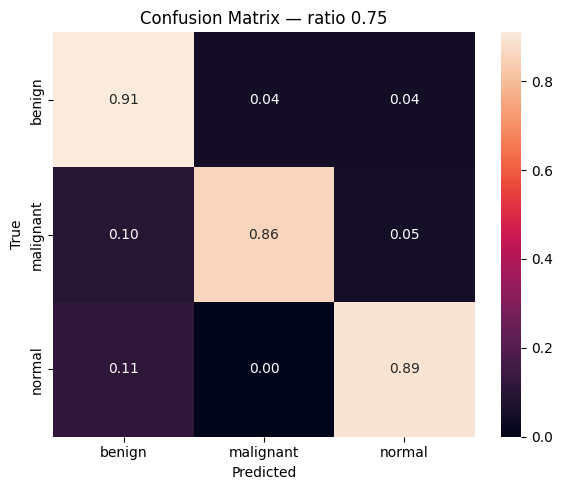

Raw counts:
 [[81  4  4]
 [ 4 36  2]
 [ 3  0 24]]


In [ ]:
# --- CONFIG: update only if your paths differ ---
WORK_DIR     = "/content/drive/MyDrive/BUSI/busi_noaug_outputs"
SPLITS_DIR   = f"{WORK_DIR}/splits"
MODEL_DIR    = f"{WORK_DIR}/clf_outputs/ratio_0_75"   # where best.pt was saved
CLASS_NAMES  = ["benign", "malignant", "normal"]

# --- Imports ---
import os, json, numpy as np, torch, torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms as T
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Dataset (matches your training transforms for eval) ---
tf_eval = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class CSVImageDataset(Dataset):
    def __init__(self, csv_path):
        import csv
        self.items = []
        with open(csv_path, newline='') as f:
            r = csv.DictReader(f)
            for row in r:
                self.items.append((row["path"], int(row["label"])))
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, y = self.items[i]
        return tf_eval(Image.open(p).convert("RGB")), y

# --- Load test set ---
test_csv = os.path.join(SPLITS_DIR, "test.csv")
ds_te = CSVImageDataset(test_csv)
dl_te = DataLoader(ds_te, batch_size=32, shuffle=False, num_workers=2)

# --- Load model ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
try:
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
except:
    model = models.resnet18(pretrained=True)  # fallback for older torchvision
model.fc = nn.Linear(model.fc.in_features, 3)
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best.pt"), map_location=device))
model = model.to(device).eval()

# --- Predict on test ---
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in dl_te:
        x = x.to(device)
        logits = model(x)
        y_pred.extend(logits.argmax(1).cpu().tolist())
        y_true.extend(y.tolist())

# --- Confusion matrix (normalized by true class) ---
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

# --- Seaborn plot ---
plt.figure(figsize=(6,5))
ax = sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — ratio 0.75")
plt.tight_layout()
plt.show()

print("Raw counts:\n", cm)


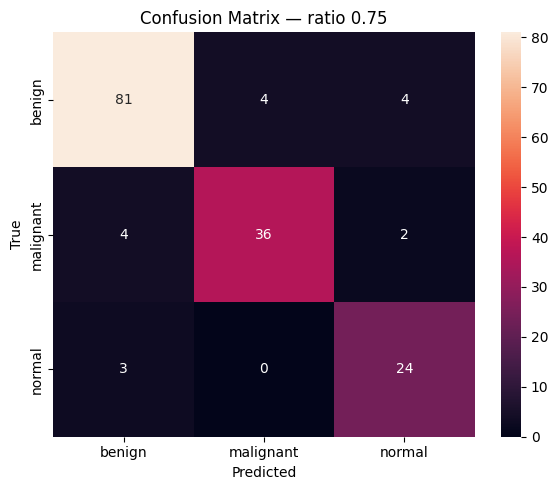

In [ ]:
# --- CONFIG: update only if your paths differ ---
WORK_DIR     = "/content/drive/MyDrive/BUSI/busi_noaug_outputs"
SPLITS_DIR   = f"{WORK_DIR}/splits"
MODEL_DIR    = f"{WORK_DIR}/clf_outputs/ratio_0_75"   # where best.pt was saved
CLASS_NAMES  = ["benign", "malignant", "normal"]

# --- Imports ---
import os, json, numpy as np, torch, torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms as T
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Dataset (matches your training transforms for eval) ---
tf_eval = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class CSVImageDataset(Dataset):
    def __init__(self, csv_path):
        import csv
        self.items = []
        with open(csv_path, newline='') as f:
            r = csv.DictReader(f)
            for row in r:
                self.items.append((row["path"], int(row["label"])))
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, y = self.items[i]
        return tf_eval(Image.open(p).convert("RGB")), y

# --- Load test set ---
test_csv = os.path.join(SPLITS_DIR, "test.csv")
ds_te = CSVImageDataset(test_csv)
dl_te = DataLoader(ds_te, batch_size=32, shuffle=False, num_workers=2)

# --- Load model ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'
try:
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
except:
    model = models.resnet18(pretrained=True)  # fallback for older torchvision
model.fc = nn.Linear(model.fc.in_features, 3)
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best.pt"), map_location=device))
model = model.to(device).eval()

# --- Predict on test ---
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in dl_te:
        x = x.to(device)
        logits = model(x)
        y_pred.extend(logits.argmax(1).cpu().tolist())
        y_true.extend(y.tolist())

# --- Confusion matrix (normalized by true class) ---
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

# --- Seaborn plot ---
plt.figure(figsize=(6,5))
ax = sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — ratio 0.75")
plt.tight_layout()
plt.show()



# test

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Spatial score: 59.2879
Spectral score: -1.5206


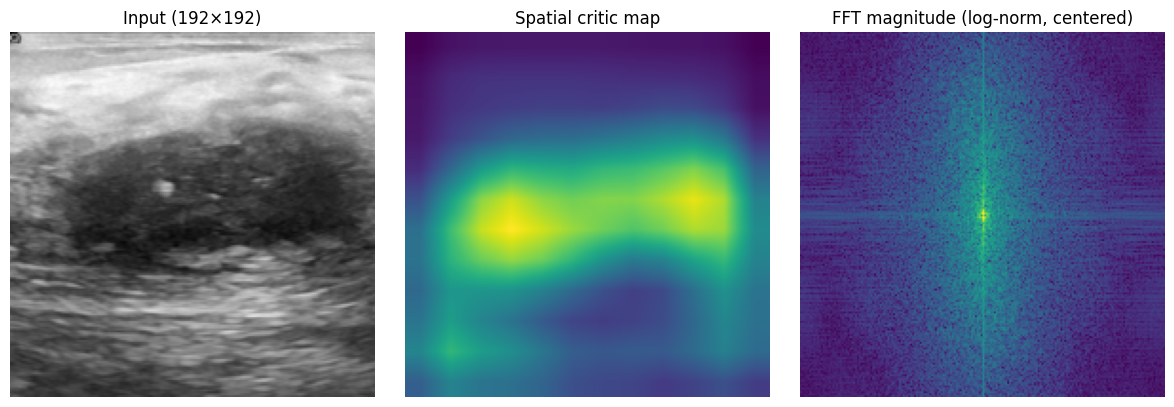

In [ ]:
# ==== CONFIG ====
IMG_PATH   = "/content/malignant (1).png"  # เปลี่ยนพาธรูปของคุณได้
SPAT_CKPT  = "/content/drive/MyDrive/BUSI/busi_noaug_outputs/fwgan_outputs/benign/ckpt/best_spatial.pt"  # เช่น "/content/drive/.../best_spatial.pt"
SPEC_CKPT  = "/content/drive/MyDrive/BUSI/busi_noaug_outputs/fwgan_outputs/benign/ckpt/best_spectral.pt"  # เช่น "/content/drive/.../best_spectral.pt"

# ==== IMPORTS ====
import torch, torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.spectral_norm as SN
from torchvision import transforms as T
from PIL import Image
import matplotlib.pyplot as plt

# ==== TRANSFORMS (ให้เข้ากับ Critics ที่คุ้น [-1,1]) ====
tf = T.Compose([
    T.Resize((192,192)),
    T.ToTensor(),
    T.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])  # -> [-1,1]
])

# ==== MODELS ====
class SpatialCritic(nn.Module):
    """PatchGAN-like critic: ให้ score ต่อภาพ + แผนที่สกอร์ต่อแพตช์"""
    def __init__(self, in_ch=3, base=64):
        super().__init__()
        self.net = nn.Sequential(
            SN(nn.Conv2d(in_ch, base,   4, 2, 1)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base, base*2,  4, 2, 1)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base*2, base*4,4, 2, 1)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base*4, base*8,4, 2, 1)), nn.LeakyReLU(0.2, True),
        )
        self.head = SN(nn.Conv2d(base*8, 1, 3, 1, 1))

    def forward(self, x, return_map=False):
        h = self.net(x)                 # [B,C,h,w] ~ 12×12 เมื่ออินพุต 192×192
        s_map = self.head(h)            # [B,1,h,w]
        s = s_map.mean(dim=[1,2,3])     # สกอร์สเกลาร์ต่อภาพ
        return (s, s_map) if return_map else s

class SpectralCritic(nn.Module):
    """Critic บน FFT-magnitude (log) ของภาพ gray: score สเกลาร์ต่อภาพ"""
    def __init__(self, in_ch=1, base=32):
        super().__init__()
        self.net = nn.Sequential(
            SN(nn.Conv2d(in_ch, base,    5, 2, 2)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base, base*2,   5, 2, 2)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base*2, base*4, 5, 2, 2)), nn.LeakyReLU(0.2, True),
            SN(nn.Conv2d(base*4, base*8, 3, 2, 1)), nn.LeakyReLU(0.2, True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(base*8, 1)

    def forward(self, x):
        # x: [B,3,H,W] ช่วง [-1,1]
        gray = (0.2989*x[:,0] + 0.5870*x[:,1] + 0.1140*x[:,2]).unsqueeze(1)    # [B,1,H,W]
        fft  = torch.fft.fft2(gray)                                            # complex
        mag  = torch.log1p(torch.abs(fft))                                     # [B,1,H,W]
        # normalize ต่อภาพ
        mag  = (mag - mag.mean(dim=[2,3], keepdim=True)) / (mag.std(dim=[2,3], keepdim=True)+1e-6)
        h    = self.net(mag)
        s    = self.fc(h.view(h.size(0), -1)).squeeze(1)                       # [B]
        return s, mag

# ==== LOAD IMAGE ====
img_pil = Image.open(IMG_PATH).convert("RGB")
x = tf(img_pil).unsqueeze(0)   # [1,3,192,192]

# ==== INIT MODELS ====
device = 'cuda' if torch.cuda.is_available() else 'cpu'
Dsp = SpatialCritic().to(device).eval()
Dsc = SpectralCritic().to(device).eval()

# (ถ้ามี ckpt ที่เทรนไว้ ให้โหลด)
if SPAT_CKPT:
    Dsp.load_state_dict(torch.load(SPAT_CKPT, map_location=device))
if SPEC_CKPT:
    Dsc.load_state_dict(torch.load(SPEC_CKPT, map_location=device))

# ==== FORWARD ====
with torch.no_grad():
    s_spat, s_map = Dsp(x.to(device), return_map=True)    # สกอร์ + แผนที่แพตช์
    s_spec, mag   = Dsc(x.to(device))                     # สกอร์เชิงสเปกตรัม + FFT-mag(norm)

print(f"Spatial score: {float(s_spat.item()):.4f}")
print(f"Spectral score: {float(s_spec.item()):.4f}")

# ==== VISUALIZE (ภาพจริง / heatmap จาก spatial-map / FFT-magnitude) ====
# 1) original (denorm)
x_show = x.clone()
x_show = (x_show*0.5 + 0.5).clamp(0,1)[0].permute(1,2,0).cpu().numpy()

# 2) spatial heatmap (upsample ให้เท่ากับ 192×192)
hm = F.interpolate(s_map, size=(192,192), mode='bilinear', align_corners=False)[0,0]
hm = (hm - hm.min()) / (hm.max()-hm.min() + 1e-6)
hm = hm.cpu().numpy()

# 3) FFT magnitude (กรอบกลาง = ค่ากลาง/ต่ำ, ขอบ = ความถี่สูง)
mag_show = torch.fft.fftshift(mag)[0,0].cpu().numpy() # Added fftshift here
mag_show = (mag_show - mag_show.min()) / (mag_show.max()-mag_show.min() + 1e-9)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Input (192×192)"); plt.axis("off"); plt.imshow(x_show)
plt.subplot(1,3,2); plt.title("Spatial critic map"); plt.axis("off"); plt.imshow(hm)
plt.subplot(1,3,3); plt.title("FFT magnitude (log-norm, centered)"); plt.axis("off"); plt.imshow(mag_show) # Updated title
plt.tight_layout(); plt.show()